<a href="https://colab.research.google.com/github/nikolasluis/Aprendizado-de-M-quina-Supervisionado---Equipe-8/blob/main/Trabalho_Pr%C3%A1tico_%E2%80%94_Compara%C3%A7%C3%A3o_de_Algoritmos_de_Aprendizado_de_M%C3%A1quina_Supervisionado_Equipe_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático — Comparação de Algoritmos de Aprendizado de Máquina Supervisionado



##Objetivo

Aplicar os conceitos de aprendizado supervisionado abordados em aula: i) KNN, ii) SVM, iii) Árvores de Decisão e iv) MLP na resolução de um problema real de **Classificação** ou **Regressão**. O trabalho tem como foco a análise comparativa de desempenho entre algoritmos, bem como a discussão crítica dos resultados obtidos.

⚠️

O notebook entregue deve ser autocontido e totalmente executável. Isso significa que:

* Todas as bibliotecas necessárias devem ser importadas explicitamente no início do notebook.

* Exceto pelo carregamento (upload) do dataset (i.e data.zip), o restante código deve ser executável do início ao fim sem intervenções manuais, sem necessidade de ajustes, inserção de inputs, descompactações e/ou modificações de caminho de arquivos.

* Todos os arquivos necessários (por exemplo, dataset processado) devem estar acessíveis via link público para download.

* O notebook deve gerar todas as saídas esperadas automaticamente, incluindo métricas, gráficos e relatórios, sem dependência de ações externas.


⚠️ Exceto pelo carregamento do dataset (i.e data.zip), trabalhos que exigirem intervenção manual (como importação adicional de bibliotecas, inserção de inputs ou correções de código) serão desconsiderados na avaliação.



##Identificação da Equipe:

* **ID GRUPO CANVAS**: 8
* **Membro 1**: Douglas Amaral
* **Membro 2**: Lucas M. Pierin
* **Membro 3**: Nicolas Kaiser
* **Membro 4**: Sérgio Kappes


⚠️ Além da identificação, **todos os membros do grupo** devem estar devidamente alocados no ambiente virtual (AVA), em:
**Pessoas → Grupos → Trabalho Final.**

⚠️ Apenas **uma submissão por grupo** é necessária. Entretanto, é imprescindível que **todos os integrantes estejam alocados** no respectivo grupo para que a atribuição do envio seja registrada corretamente.


##Seed

In [59]:
# Imports iniciais
import os
import random
import sklearn
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_blobs, make_classification
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC as SVM
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


# Definição de semente para reprodutibilidade
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

#Definição e Descrição do Dataset

### Seleção do Dataset

Selecione um **dataset público** disponível no [Kaggle – Categoria Classification](https://www.kaggle.com/datasets?tags=13302-Classification), que contenha **rótulos (labels)**, caracterizando uma tarefa de **classificação binária** ou **multiclasse**.

O dataset escolhido deve apresentar **quantidade suficiente de instâncias e atributos** para permitir uma análise estatística e experimental significativa.

Caso o dataset tenha sido **pré-processado** (por exemplo: limpeza, seleção de atributos, codificação ou balanceamento), o **arquivo resultante** deve ser compartilhado em um link público (Google Drive, Dropbox, etc.), de modo que possa ser baixado e executado sem restrições.

> 🔗 **LINK PARA O DATASET:**
> *(Insira aqui o link direto para o dataset original ou processado)* <<==

⚠️ **Observação:** Trabalhos sem o link de acesso ao dataset não serão avaliados, pois impedem a reprodutibilidade do experimento.



---



##Descreva sucitamente o dataset (aplicação, desafios, etc)



---

#Preparação dos Dados

Nesta seção, desenvolva **rotinas** para o tratamento do dataset selecionado, contemplando as seguintes etapas:

* **Descompactação e Importação:** implemente a leitura direta do arquivo (CSV, XLSX, ZIP, etc.), garantindo o correto carregamento dos dados.
* **Limpeza e Pré-processamento:** realize as etapas necessárias de tratamento, como remoção de valores ausentes, codificação de variáveis categóricas, normalização ou padronização, e balanceamento das classes, quando aplicável.
* **Divisão dos Conjuntos:** separe o dataset em **treino, validação e teste**, utilizando o método **Holdout** de forma adequada à natureza do problema.
* **Análise Exploratória:** elabore **gráficos e estatísticas descritivas** que permitam compreender a distribuição das variáveis, a correlação entre atributos e o equilíbrio entre as classes.

**Descompactação e Importação**

In [60]:
file_path = 'heart.csv'

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  'fedesoriano/heart-failure-prediction',
  file_path
)

/var/folders/g8/yv_f6b4n1v99gwczsdrrkvlc0000gn/T/ipykernel_80519/3479902626.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


**Limpeza e Pré-Processamento**

In [61]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

col_qualitativas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
col_quantitativas =  ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS']

preprocessador = ColumnTransformer([
    ('quantitativas', StandardScaler(), col_quantitativas),
    ('qualitativas', OneHotEncoder(drop='first'), col_qualitativas)
])

**Divisão dos conjuntos**

In [62]:
test_size = 0.2
random_state = SEED

x_train, x_test, y_train, y_test, = train_test_split(x, y, test_size=test_size, random_state=random_state)
x_train, x_val, y_train, y_val, = train_test_split(x_train, y_train, test_size=test_size, random_state=random_state)

print(f"Treino: {len(x_train)} | Validação: {len(x_val)} | Teste: {len(x_test)}")

Treino: 587 | Validação: 147 | Teste: 184


**Anánlise Exploratória**

*Correlação entre variavéis numéricas*

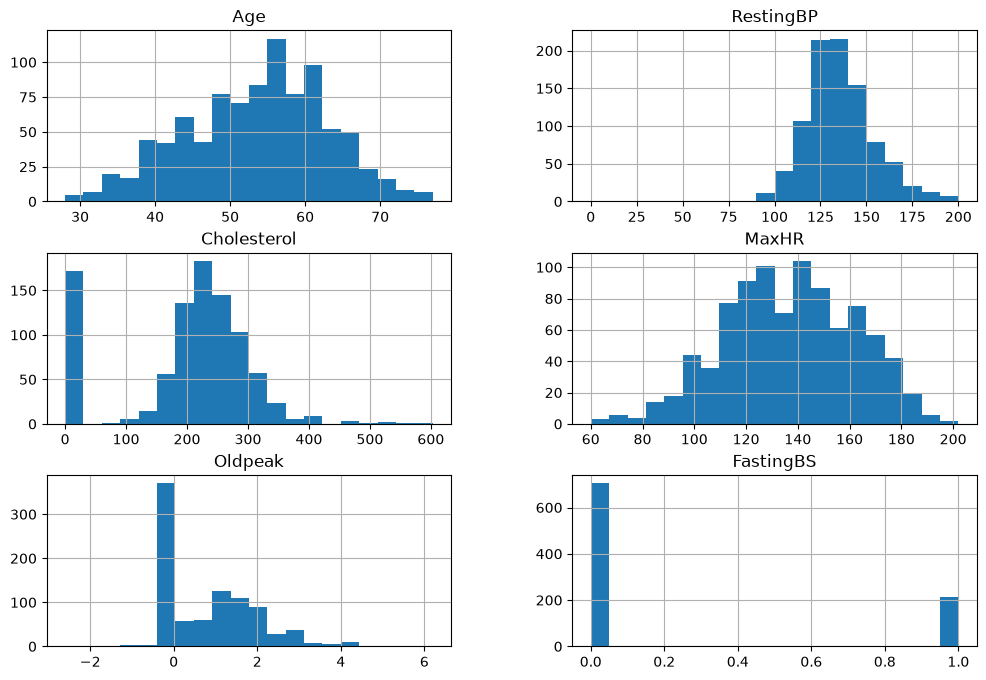

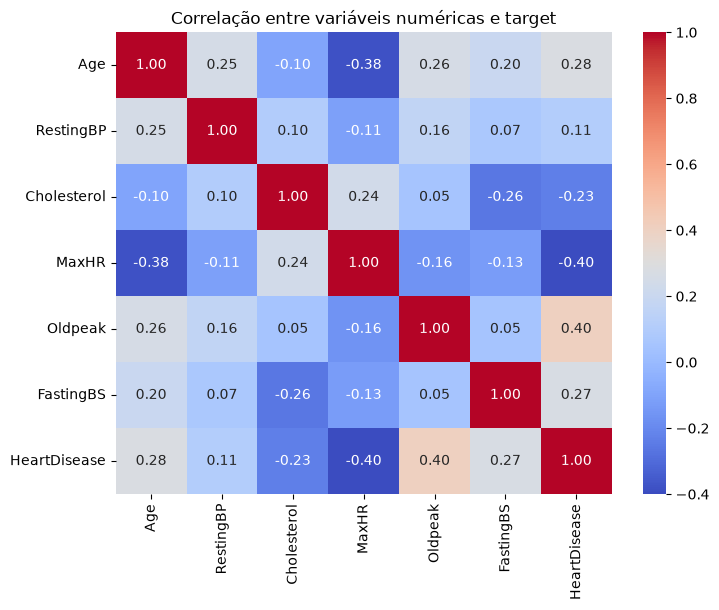

In [63]:
df[col_quantitativas].hist(bins=20, figsize=(12,8))

plt.figure(figsize=(8,6))
sns.heatmap(df[col_quantitativas + ['HeartDisease']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis numéricas e target')
plt.show()

*Distribuição de classes (equilíbrio entre as classes)*

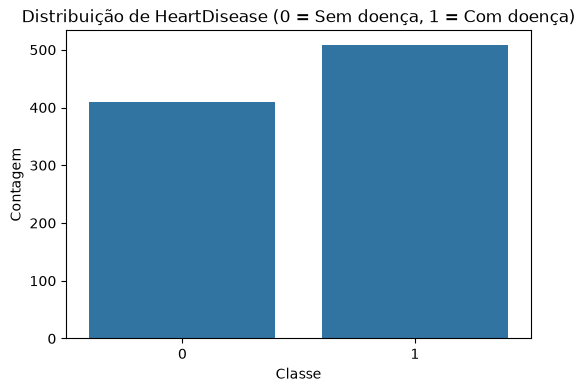

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [64]:
plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=df)
plt.title('Distribuição de HeartDisease (0 = Sem doença, 1 = Com doença)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

# Proporções
print(df['HeartDisease'].value_counts(normalize=True))

---

#Implementação dos Modelos

Treinar e testar os seguintes algoritmos:

* K-Nearest Neighbors (KNN)

* Support Vector Machine (SVM)

* Decision Tree (Árvore de Decisão)

* Multi-Layer Perceptron (MLP)


**Implementação do modelo**

*Modelo KNN*

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, train_size=0.7, test_size=0.3, random_state=SEED, stratify=y
)

print(f"Dimensões do Treino: {X_train.shape}")
print(f"Dimensões do Teste: {X_test.shape}\n")

# Pipeline com KNN (K=5 vizinhos)
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)

pipeline_knn = Pipeline([
    ('preprocessor', preprocessador),
    ('classifier', knn_model)
])

# Treinamento
pipeline_knn.fit(X_train, y_train)

# Predições
y_pred = pipeline_knn.predict(X_test)


Dimensões do Treino: (642, 11)
Dimensões do Teste: (276, 11)



Métricas KNN

Acc no Teste: 0.8696

--- RELATÓRIO DE CLASSIFICAÇÃO ---
                precision    recall  f1-score   support

Sem Doença (0)       0.88      0.81      0.85       123
Com Doença (1)       0.86      0.92      0.89       153

      accuracy                           0.87       276
     macro avg       0.87      0.86      0.87       276
  weighted avg       0.87      0.87      0.87       276


--- MATRIZ DE CONFUSÃO ---


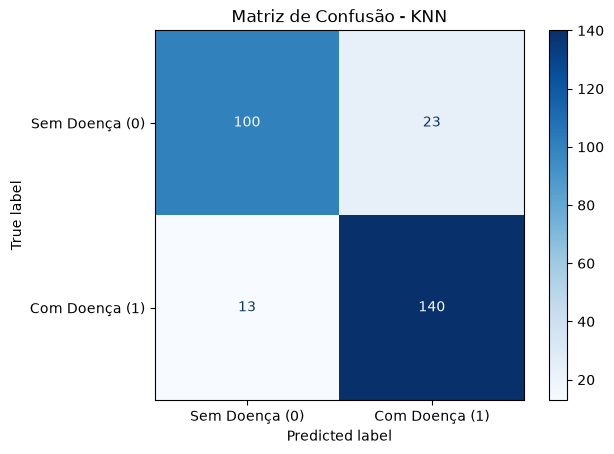

In [66]:
acc = accuracy_score(y_test, y_pred)
print(f'Acc no Teste: {acc:.4f}\n')

print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred, target_names=['Sem Doença (0)', 'Com Doença (1)']))

print("\n--- MATRIZ DE CONFUSÃO ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sem Doença (0)', 'Com Doença (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - KNN')
plt.show()

Análise KNN

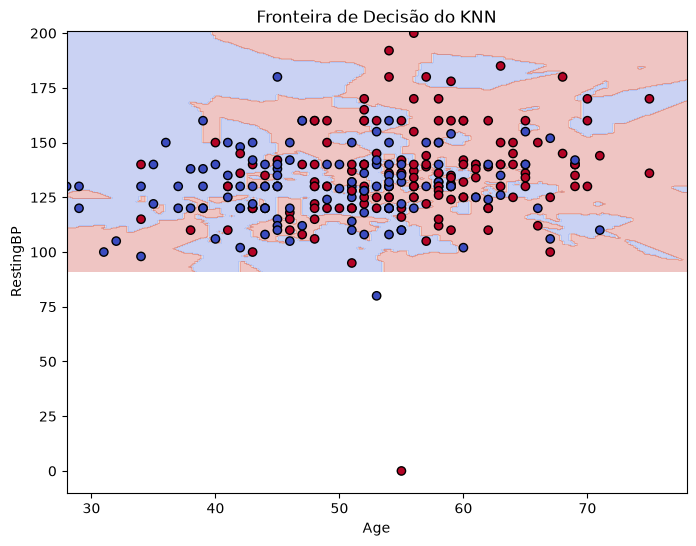

In [67]:
preprocessor_2d = ColumnTransformer([
    ('quantitativas', StandardScaler(), ['Age', 'RestingBP'])
])
pipeline_2d = Pipeline([('prep', preprocessor_2d), ('clf', KNeighborsClassifier(n_neighbors=5))])
pipeline_2d.fit(X_train[['Age', 'RestingBP']], y_train)

fig, ax = plt.subplots(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    pipeline_2d, X_train[['Age', 'RestingBP']], response_method="predict",
    cmap="coolwarm", alpha=0.3, ax=ax, grid_resolution=200
)

# 'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS'
scatter = ax.scatter(X_test['Age'], X_test['RestingBP'], c=y_test, cmap="coolwarm", edgecolors="k")
ax.set_xlabel('Age')
ax.set_ylabel('RestingBP')
ax.set_title('Fronteira de Decisão do KNN')
plt.show()

*Modelo RBF*

In [68]:
test_size = 0.2
random_state = SEED

x_train, x_test, y_train, y_test, = train_test_split(x, y, test_size=test_size, random_state=random_state)
x_train, x_val, y_train, y_val, = train_test_split(x_train, y_train, test_size=test_size, random_state=random_state)

print(f"Treino: {len(x_train)} | Validação: {len(x_val)} | Teste: {len(x_test)}")

Treino: 587 | Validação: 147 | Teste: 184


In [69]:
modelo_rbf = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='rbf'))
])
modelo_rbf.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quantitativas', ...), ('qualitativas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

*Modelo Linear*

In [70]:
modelo_linear = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='linear'))
])
modelo_linear.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quantitativas', ...), ('qualitativas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

*Modelo Polinomial*

In [71]:
modelo_poly = Pipeline([
    ('preprocess', preprocessador),
    ('svm', SVM(kernel='poly'))
])
modelo_poly.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('quantitativas', ...), ('qualitativas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

---

#Avaliação dos modelos


* Calcular e comparar as métricas: Acurácia, Precisão, Recall e F1-Score.


* Plotar e comentar as matrizes de confusão.


* Discutir o impacto dos hiperparâmetros e preprocessamentos aplicados.

Aqui você pode elaborar gráficos, analises de resultados da maneira que desejar. No entanto, espera-se uma breve discussão dos resultados e análises críticas.


*Modelo RBF*

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        77
           1       0.88      0.88      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



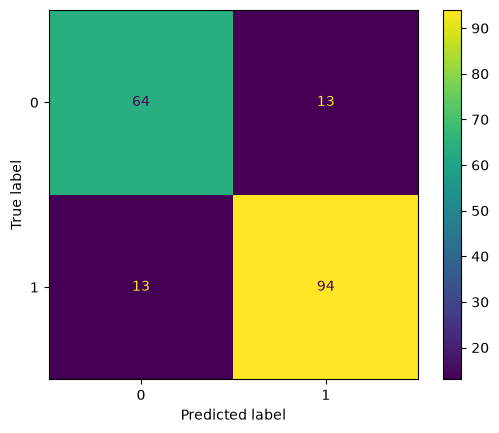

In [72]:
y_pred = modelo_rbf.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=modelo_rbf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=modelo_rbf.classes_)
disp.plot()

plt.show()

              precision    recall  f1-score   support

           0       0.81      0.84      0.83        77
           1       0.88      0.86      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



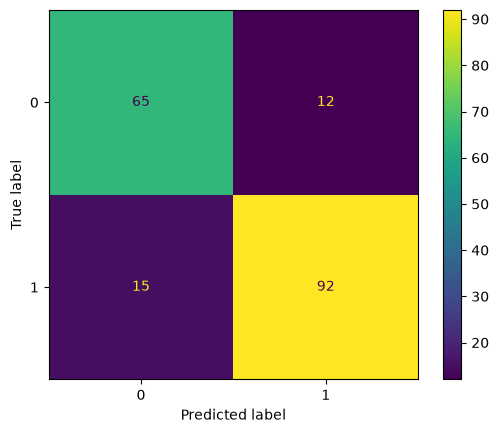

In [73]:
y_pred = modelo_linear.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=modelo_linear.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=modelo_linear.classes_)
disp.plot()

plt.show()

              precision    recall  f1-score   support

           0       0.80      0.90      0.85        77
           1       0.92      0.84      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



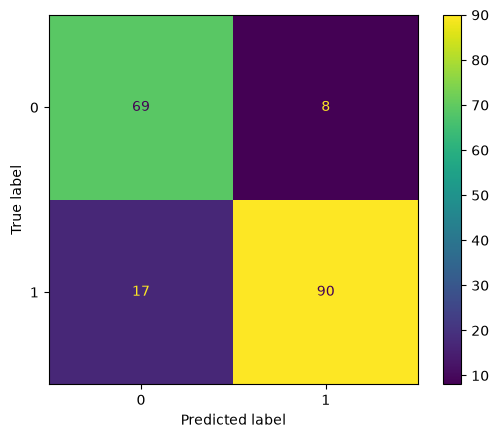

In [74]:
y_pred = modelo_poly.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=modelo_poly.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=modelo_poly.classes_)
disp.plot()

plt.show()

Em conformidade com os resultados apresentados pelas matrizes de confusão e métricas plotadas, define-se que o melhor entre os três modelos gerados para o SVM é o RBF. Entre eles, é o mais assertivo em relação ao número de doentes detectados, com recall de 88% (perdendo apenas 13 pacientes em 107), contra 86% e 84% dos modelos linear e polinomial, respectivamente, conforme demonstram os recalls. Em contrapartida, o modelo polinomial gera menos falsos positivos (8 contra 13 do RBF), mas erra o diagnóstico de 17 pacientes doentes (falsos negativos), ou seja, 4 a mais que o RBF. Considerando a matriz de confusão do RBF, percebe-se que o número de pacientes erroneamente diagnosticados é o mesmo para ambas as classes (13 falsos positivos e 13 falsos negativos), indicando que as classes são tratadas de forma igualitária, enquanto para os outros dois modelos esses números variam significativamente. Desta forma, podemos adotar o modelo RBF como um modelo equilibrado entre as classes, sendo o mais recomendado para utilização sobre os demais.

In [75]:
x['Sex'] = x["Sex"].map({'M': 0, 'F': 1})
x['ChestPainType'] = x["ChestPainType"].map({'TA': 0, 'ATA': 1, 'NAP': 2, 'ASY': 3})
x['RestingECG'] = x["RestingECG"].map({'Normal': 0, 'ST': 1, 'LVH': 2})
x['ExerciseAngina'] = x["ExerciseAngina"].map({'N': 0, 'Y': 1})
x['ST_Slope'] = x["ST_Slope"].map({'Up': 0, 'Flat': 1, 'Down': 2})

x_train, x_test, y_train, y_test, = train_test_split(x, y, test_size=test_size, random_state=random_state)
x_train, x_val, y_train, y_val, = train_test_split(x_train, y_train, test_size=test_size, random_state=random_state)


In [76]:
from sklearn.neural_network import MLPClassifier
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=1000,
        random_state=SEED
    ))
])

param_grid = {
    "mlp__hidden_layer_sizes": [
        (8, 4),(8, 8),(8, 12),
        (12, 6),(12, 12),(12, 16),
        (16, 8),(16, 16),(16, 24),
        (2,2,2),(4,4,4),(6,6,6),
        (8,8,8),(12,12,12),
        (10, 10, 10),(16, 16, 16)
    ],
    "mlp__activation": ['relu', 'identity', 'logistic', 'tanh'],
    "mlp__solver": ['lbfgs', 'adam'],
    "mlp__alpha": [0.0001, 0.001, 0.01],
    "mlp__learning_rate_init": [0.001, 0.01]
}


In [77]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_ra

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_r

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learnin

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learnin

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__lea

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__lea

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__lear

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4),

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 1

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(1

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_la

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.0001, mlp__hidden_lay

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_ra

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learni

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_ra

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learni

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__le

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__l

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), ml

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_s

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_si

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.001, mlp__hidden_layer_size

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_ini

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_ra

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_in

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_i

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learn

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(1

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=relu, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_siz

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_size

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_lay

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_lay

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidde

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_lay

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) rea

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__al

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidd

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) rea

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_siz

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_siz

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_la

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidd

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hid

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_lay

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hi

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hi

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_si

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__le

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12),

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_si

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_size

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.0s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_laye

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check


[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_l

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_la

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=logistic, mlp__alpha=0.01

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=logistic, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_r

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learni

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 12), mlp__learn

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12), mlp__lea

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__lear

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__l

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learn

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__lear

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 24), mlp_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.6s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6),

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(8, 8, 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_la

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_laye

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.0001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) rea

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rat

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learni

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_r

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_r

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learni

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), ml

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4),

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(6, 6, 6), mlp_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_siz

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_siz

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.001, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.7s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8), mlp__learning_rate_init=0.01, mlp

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 12), mlp__learning_rate_init=0.0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.8s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_ini

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16), mlp__learning_rate_in

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_i

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 24), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learnin

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(2, 2, 2), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.6s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (s

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(4, 4, 4), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.7s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.4s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.4s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.5s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(6, 6, 6), mlp__lea

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(8, 8, 8), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 1

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.2s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.01, mlp__solver=adam; total time=   0.3s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(12, 12, 12), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.01, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10,

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=lbfgs; total time=   0.1s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(10, 10, 10), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(1

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   1.0s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s
[CV] END mlp__activation=tanh, mlp__alpha=0.01, mlp__hidden_layer_sizes=(16, 16, 16), mlp__learning_rate_init=0.001, mlp__solver=adam; total time=   0.9s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'mlp__activation': ['relu', 'identity', ...], 'mlp__alpha': [0.0001, 0.001, ...], 'mlp__hidden_layer_sizes': [(8, ...), (8, ...), ...], 'mlp__learning_rate_init': [0.001, 0.01], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` 

Melhores parâmetros:
{'mlp__activation': 'logistic', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (4, 4, 4), 'mlp__learning_rate_init': 0.001, 'mlp__solver': 'adam'}
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        77
           1       0.90      0.83      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



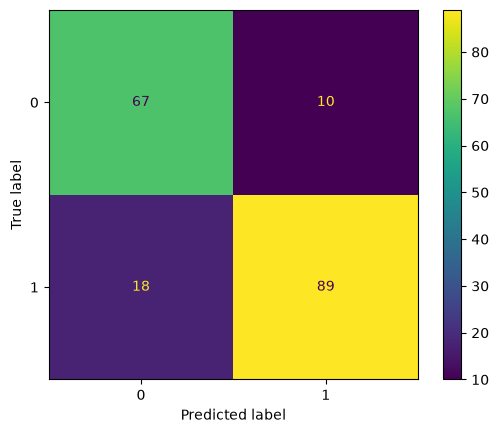

In [78]:
best_model = grid_search.best_estimator_

print("Melhores parâmetros:")
print(grid_search.best_params_)

y_pred = best_model.predict(x_test)

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=best_model.classes_)
disp.plot()

plt.show()

Acurácia: 0.8260869565217391
Matriz de Confusão:
 [[ 96  16]
 [ 32 132]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80       112
           1       0.89      0.80      0.85       164

    accuracy                           0.83       276
   macro avg       0.82      0.83      0.82       276
weighted avg       0.83      0.83      0.83       276



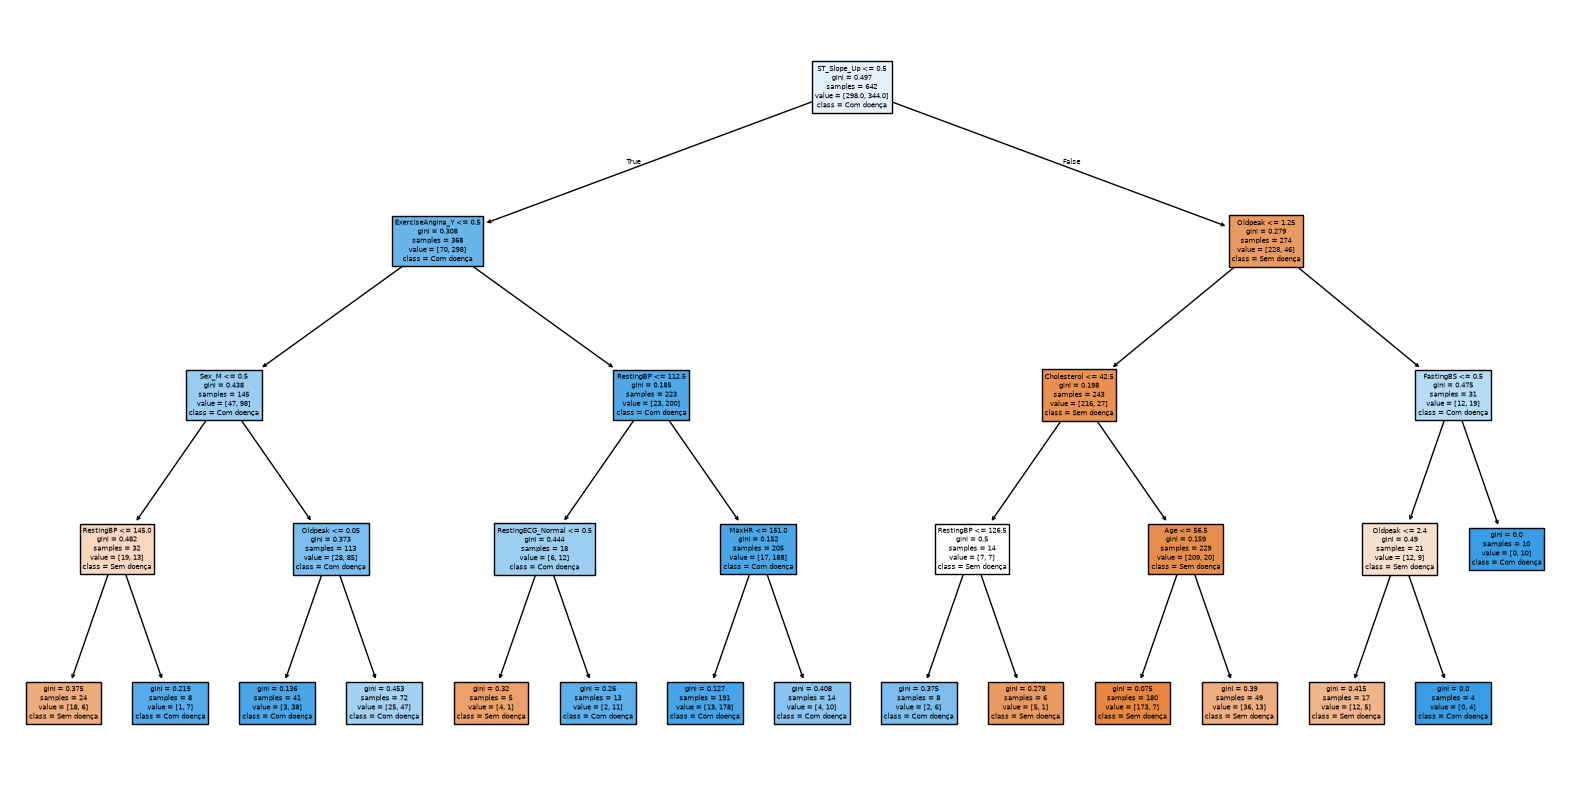

In [79]:
# 3. Separar features (X) e target (y)
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# 4. Transformar variáveis categóricas em numéricas
X = pd.get_dummies(X, drop_first=True)

# 5. Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Criar e treinar o modelo
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# 7. Fazer previsões
y_pred = model.predict(X_test)

# 8. Avaliar desempenho
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred))
print("Relatório de Classificação:\n", classification_report(y_test, y_pred))

# 9. Visualizar a árvore
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=["Sem doença","Com doença"], filled=True)
plt.show()

Raiz (primeiro nó):

A árvore começa dividindo pela variável ST_Slope_Up.

Isso significa que o modelo considera a inclinação do segmento ST como o fator mais importante para separar pacientes com e sem doença.

O nó mostra:

gini = 0.497 → medida de impureza (quanto mais próximo de 0, mais puro).

samples = 842 → número de pacientes avaliados nesse ponto.

value = [298, 544] → distribuição entre classes (298 sem doença, 544 com doença).

class = Com doença → classe majoritária nesse nó.

Ramos (branches):

Cada condição (ex.: ExerciseAngina_Y <= 0.5) representa uma regra de decisão.

Se a condição é verdadeira, segue pelo ramo da esquerda; se é falsa, pelo da direita.

Isso vai refinando a classificação até chegar às folhas.

Folhas (leaves):

São os nós finais, onde não há mais divisão.

Cada folha mostra a classe prevista (sem doença ou com doença), junto com a pureza (gini) e a quantidade de amostras que chegaram até ali.

Exemplo: uma folha pode ter gini = 0.073, samples = 230, value = [221, 9], class = Sem doença.

Isso significa que, dos 230 pacientes que chegaram a esse ponto, 221 não têm doença e apenas 9 têm.

O modelo então classifica como sem doença.

Cores Azul → nós onde a classe majoritária é com doença.

Laranja → nós onde a classe majoritária é sem doença.

Quanto mais forte a cor, mais puro é o nó (menos mistura entre classes).

Profundidade da árvore: 4
Número de nós: 15


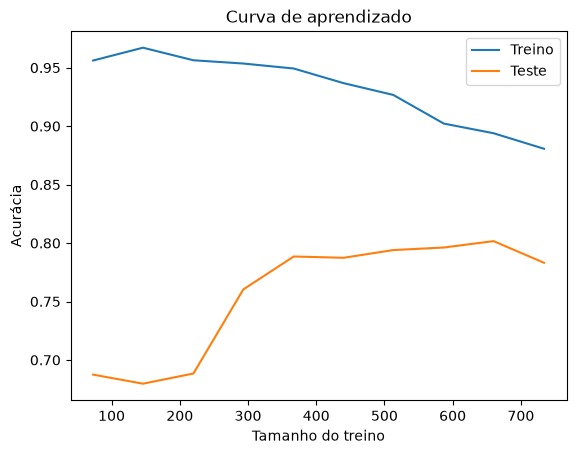

In [80]:

print("Profundidade da árvore:", model.get_depth())
print("Número de nós:", model.get_n_leaves())

from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Treino")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Teste")
plt.xlabel("Tamanho do treino")
plt.ylabel("Acurácia")
plt.legend()
plt.title("Curva de aprendizado")
plt.show()


---

# Discussão, análise crítica e conclusão


* Apresentar e discutir o modelo de melhor desempenho e justificar tecnicamente

* Apresentar e discutir as limitações e possíveis desafios.


Em conformidade com os resultados apresentados pelas matrizes de confusão e métricas plotadas, define-se que o melhor entre os quatro modelos gerados é o KNN. 

Entre eles, é o mais assertivo em relação ao número de doentes detectados, com recall de 92%, contra 83% e 86% dos modelos decision tree, MLP e SVM, respectivamente, conforme demonstram os recalls. 

O princípio básico do KNN é o aprendizado baseado em analogia: ele assume que instâncias que estão próximas no espaço de atributos compartilham a mesma classe. Na medicina, isso faz total sentido,se um novo paciente apresenta idade, pressão arterial, colesterol e sintomas (como angina) muito parecidos com os de um grupo de K pacientes que já foram diagnosticados com insuficiência cardíaca, a probabilidade de esse novo paciente também ter a doença é altíssima

Desta forma, podemos adotar o modelo KNN como o modelo que apresentou a melhor acuracia detectando pacientes com doenças cardiacas, superando os outros modelos testados.



---

#Submissão

O notebook desenvolvido no Google Colab deve ser exportado em formato PDF por meio da opção:
Arquivo → Imprimir → Salvar como PDF.

É obrigatório que o arquivo PDF contenha todas as células processadas, exibindo os resultados, gráficos e métricas gerados durante a execução. Trabalhos submetidos com células não executadas ou sem resultados visíveis não serão avaliados.

A submissão deve seguir as seguintes orientações:

O envio deve ser feito por apenas um integrante do grupo, previamente cadastrado no AVA.

O notebook Colab original deve estar compartilhado publicamente (ou com permissão de visualização) e o link de acesso deve ser inserido abaixo:

🔗 LINK PARA O COLAB:
(Insira aqui o link de compartilhamento do notebook no Google Colab)

Essa etapa permite ao professor a verificação do código-fonte completo, dos procedimentos de análise e da reprodutibilidade dos resultados.


BOM TRABALHO!! ✅ !!!

---
